In [3]:
import sys
sys.path.append("/user/christoph.wald/u15287/insect_pest_detection/modules")
import cv2
import matplotlib.pyplot as plt
from modules_segmentation import *
from modules_augmentation import *
import random
import os

### Load empty image

In [5]:
image_folder = "/user/christoph.wald/u15287/big-scratch/00_uncropped_dataset/emptyYST"
image_files = os.listdir(image_folder)
empty_YSTs = []
for f in image_files:
    empty_YSTs.append(cv2.imread(os.path.join(image_folder, f)))

### Shear to create augmentations

In [6]:
sheared_YSTs = []
for YST in empty_YSTs:
    sheared_YSTs.append(YST)
    sheared_YSTs.append(random_shear(YST))
    sheared_YSTs.append(random_shear(YST))

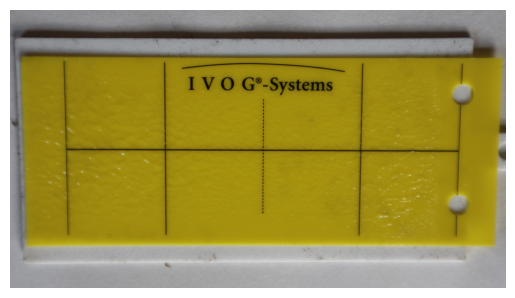

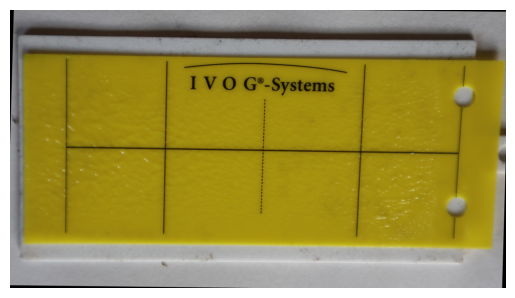

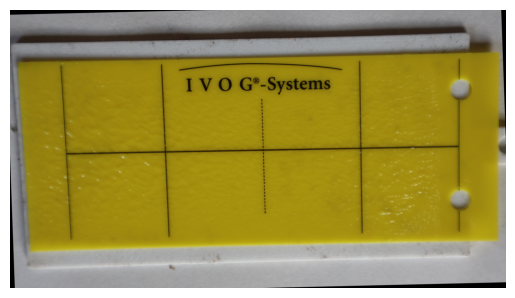

In [7]:
show(sheared_YSTs[0])
show(sheared_YSTs[1])
show(sheared_YSTs[2])

In [8]:
import cv2
import numpy as np

def adjust_saturation(image, factor: float):
    """
    Adjusts the saturation of an image.

    Parameters:
        image (numpy.ndarray): Input BGR image (as read by cv2.imread)
        factor (float): 
            - 1.0 = no change
            - >1.0 = increase saturation
            - <1.0 = decrease saturation
            - 0.0 = fully desaturated (grayscale)

    Returns:
        numpy.ndarray: The saturation-adjusted image (BGR)
    """
    # Convert BGR → HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV).astype(np.float32)
    
    # Scale the saturation channel (S)
    hsv[..., 1] *= factor
    
    # Clip values to [0, 255]
    hsv[..., 1] = np.clip(hsv[..., 1], 0, 255)
    
    # Convert back to BGR
    saturated = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)
    return saturated


In [9]:
import cv2
import numpy as np
import random

def random_light_variation(image):
    """
    Apply a random daylight-like variation to an image by adjusting
    color balance, brightness, and saturation — without using named presets.
    
    Parameters:
        image (numpy.ndarray): Input BGR image.
    
    Returns:
        numpy.ndarray: The adjusted image.
    """
    img = image.astype(np.float32) / 255.0

    # --- Randomize approximate "temperature" range (cool ↔ warm)
    #  Lower values -> warmer (more red/yellow)
    #  Higher values -> cooler (more blue)
    t_value = random.uniform(4500, 7500)
    t_norm = np.clip(t_value, 1000, 40000) / 100.0

    # Compute simple color balance vector
    if t_norm <= 66:
        r = 255
        g = 99.47 * np.log(t_norm) - 161.12
        b = 0 if t_norm <= 19 else 138.52 * np.log(t_norm - 10) - 305.04
    else:
        r = 329.70 * ((t_norm - 60) ** -0.1332)
        g = 288.12 * ((t_norm - 60) ** -0.0755)
        b = 255
    balance = np.clip(np.array([b, g, r]) / 255.0, 0, 1)

    # --- Randomize brightness and saturation ---
    brightness_factor = random.uniform(0.8, 1.3)
    saturation_factor = random.uniform(0.8, 1.4)

    # --- Apply color balance ---
    img *= balance
    img = np.clip(img, 0, 1)

    # --- Apply brightness ---
    img *= brightness_factor
    img = np.clip(img, 0, 1)

    # --- Apply saturation ---
    hsv = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[..., 1] *= saturation_factor
    hsv[..., 1] = np.clip(hsv[..., 1], 0, 255)
    result = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

    return result


In [10]:
import cv2
import numpy as np
import random

def random_local_blur(image, area_ratio=0.1):
    """
    Apply blur to a random small region of the image (simulating out-of-focus spot).

    Parameters:
        image (numpy.ndarray): Input BGR image.
        area_ratio (float): Approx. fraction of total area to blur (default 0.1 = 10%)

    Returns:
        numpy.ndarray: Image with a locally blurred region.
    """
    h, w = image.shape[:2]
    output = image.copy()

    # --- Determine patch size (√area_ratio of image) ---
    patch_ratio = np.sqrt(area_ratio)
    patch_h = int(h * patch_ratio)
    patch_w = int(w * patch_ratio)

    # --- Random top-left corner for the patch ---
    x1 = random.randint(0, max(1, w - patch_w))
    y1 = random.randint(0, max(1, h - patch_h))
    x2 = x1 + patch_w
    y2 = y1 + patch_h

    # --- Extract patch and blur it ---
    patch = output[y1:y2, x1:x2]
    ksize = random.choice([51, 71, 61, 91]) # random blur kernel
    patch_blurred = cv2.GaussianBlur(patch, (ksize, ksize), 0)

    # --- Optional: blend smoothly with surroundings (soft edges) ---
    mask = np.zeros((patch_h, patch_w), np.float32)
    cv2.circle(mask, (patch_w // 2, patch_h // 2), min(patch_w, patch_h) // 2, 1, -1)
    mask = cv2.GaussianBlur(mask, (31, 31), 0)
    mask = mask[..., None]  # to broadcast across channels

    # Blend blurred patch into original region
    blended = patch_blurred * mask + patch * (1 - mask)
    output[y1:y2, x1:x2] = blended.astype(np.uint8)

    return output


### Create masks to find the areas where to place the insects

In [11]:
processed_mask = cv2.imread(
    #"/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/06_generated_mask_fat_plus.jpg", 
    "/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/04_generated_mask_fat.jpg",
    cv2.IMREAD_GRAYSCALE
)

gridcorners = np.load("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/gridcorners.npy")
mask_h_line = np.load("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/mask_h_line.npy")

image_files = os.listdir(image_folder)

def get_mask(image, mask, gridcorners, mask_h_line):
    #Load image file
    #print(f"Loading {image_file}")
    #image = cv2.imread(os.path.join(image_folder, image_file))

    #find YST contour of image
    imageYST = find_contour(image)

    #save cropped image
    x, y, w, h = cv2.boundingRect(imageYST)
    

    #find corners if possible, if not skip the image
    imagecorners = find_corners(image, imageYST)
    if len(imagecorners) == 0:
        print(f"No YST found for {image_file}")
        return None

    #find transformation
    H, _ = cv2.findHomography(gridcorners, imagecorners, cv2.RANSAC)

    #first transformation: 
    mask = cv2.warpPerspective(processed_mask, H, (image.shape[1], image.shape[0]))
    
    #transform midline of mask as above
    h_line_pts = mask_h_line.reshape(-1,1,2)
    h_line_pts_warped = cv2.perspectiveTransform(h_line_pts, H)
    x1w, y1w, x2w, y2w = h_line_pts_warped.reshape(-1).astype(np.int32)
    mask_h = (x1w, y1w, x2w, y2w)

    #second transformation: correct vertical misalignment
    dy = get_distance_h_mid(create_binary_mask(image), mask_h)
    H, W = mask.shape[:2]
    M = np.float32([[1, 0, 0], [0, 1, dy]])  # translation matrix
    mask= cv2.warpAffine(mask, M, (W, H), borderValue=255)  # white background
    return mask[y:y+h, x:x+w]

In [12]:
masks = []
for YST in sheared_YSTs:
    masks.append(get_mask(YST, processed_mask, gridcorners, mask_h_line))



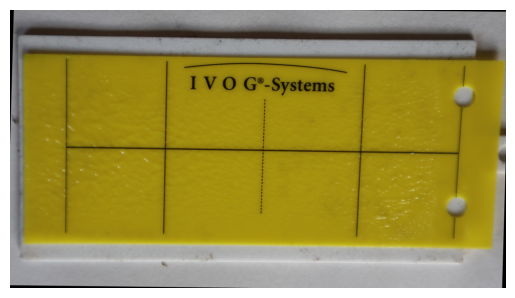

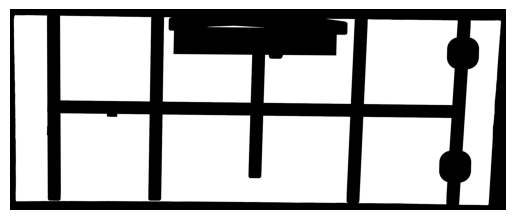

In [13]:
show(sheared_YSTs[1])
show(masks[1])

### get cut out insects

In [107]:
# Paths
label_path = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/05_created_labels"
image_path = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/04_images_cropped"
label_files = os.listdir(label_path)

# Pest types
pest_types = ["BRAIIM", "LIRIBO", "FRANOC", "TRIAVA"]
all_insects = [[], [], [], []]


for filename in label_files:
    #print(filename)
    cls = [id in filename for id in pest_types].index(True)

    abs_boxes = []
    with open(os.path.join(label_path, filename), 'r') as f:
        for line in f:
            if line.strip():
                x, y, w, h = map(float, ast.literal_eval(line))
                x1, y1, x2, y2 = x, y, x + w, y + h
                abs_boxes.append([x1, y1, x2, y2])

    image = cv2.imread(os.path.join(image_path, os.path.splitext(filename)[0] + ".jpg"))
    rectangles = [enlarge_box(box, image.shape, scale=1) for box in abs_boxes]

    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    insects = []

    for box in rectangles:
        x1, y1, x2, y2 = map(int, box)
        region_bgr = image[y1:y2, x1:x2]
        if region_bgr.size == 0:
            continue

        region_hsv = hsv_image[y1:y2, x1:x2]
        value = region_hsv[:, :, 2]

        otsu_thresh, binary_mask = cv2.threshold(value, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        binary_mask_inv = cv2.bitwise_not(binary_mask)

        foreground = cv2.bitwise_and(region_bgr, region_bgr, mask=binary_mask_inv)
        background = np.full_like(region_bgr, 255)
        result = np.where(binary_mask_inv[:, :, np.newaxis] == 0, background, foreground)

        # ✅ Keep only the main (central) contour
        #result = keep_central_contour(result)

        insects.append(result)

    all_insects[cls].extend(insects)

In [ ]:
# Paths
label_path = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/05_created_labels"
image_path = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/04_images_cropped"
label_files = os.listdir(label_path)

# Pest types
pest_types = ["BRAIIM", "LIRIBO", "FRANOC", "TRIAVA"]
all_insects = [[], [], [], []]
counter = 0

for filename in label_files:
    if not filename.startswith("TRIAVA"):
        continue
    #print(filename)
    counter += 1
    cls = [id in filename for id in pest_types].index(True)

    abs_boxes = []
    with open(os.path.join(label_path, filename), 'r') as f:
        for line in f:
            if line.strip():
                x, y, w, h = map(float, ast.literal_eval(line))
                x1, y1, x2, y2 = x, y, x + w, y + h
                abs_boxes.append([x1, y1, x2, y2])

    image = cv2.imread(os.path.join(image_path, os.path.splitext(filename)[0] + ".jpg"))
    rectangles = [enlarge_box(box, image.shape, scale=1) for box in abs_boxes]

    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    insects = []

    for box in rectangles:
        x1, y1, x2, y2 = map(int, box)
        region_bgr = image[y1:y2, x1:x2]
        if region_bgr.size == 0:
            continue
        
        
        
        region_hsv = hsv_image[y1:y2, x1:x2]
        #show(region_bgr)
        binary_mask = create_binary_mask(region_hsv)

        # Apply mask
        foreground = cv2.bitwise_and(region_bgr, region_bgr, mask=binary_mask)
        background = np.full_like(region_bgr, 255)
        result = np.where(binary_mask[:, :, np.newaxis] == 0, background, foreground)
        #show(result)

        # Step 1: Convert to grayscale to detect white pixels
        gray = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)
        white_mask = (gray >= 250).astype(np.uint8)  # 1 = white, 0 = non-white

        # Step 2: Create a copy to visualize
        visual = result.copy()

        # Step 3: Prepare mask for floodFill (2 pixels larger)
        h, w = white_mask.shape
        flood_mask = np.zeros((h+2, w+2), np.uint8)

        # Step 4: Flood-fill all border-connected white pixels in red
        for x in range(w):
            if white_mask[0, x]:
                cv2.floodFill(visual, flood_mask, (x, 0), (0, 0, 255))  # red
            if white_mask[h-1, x]:
                cv2.floodFill(visual, flood_mask, (x, h-1), (0, 0, 255))
        for y in range(h):
            if white_mask[y, 0]:
                cv2.floodFill(visual, flood_mask, (0, y), (0, 0, 255))
            if white_mask[y, w-1]:
                cv2.floodFill(visual, flood_mask, (w-1, y), (0, 0, 255))

        # Step 5: Find internal white pixels (still white in visual)
        internal_white_mask = np.all(visual == result, axis=2) & (white_mask == 1)

        # Step 6: Color internal white pixels blue
        visual[internal_white_mask] = (255, 0, 0)  # BGR blue

        # Show the result
        #show(visual)

        
        # Step 1: Identify blue pixels in visual (internal white)
        blue_mask = (visual[:, :, 0] == 255) & (visual[:, :, 1] == 0) & (visual[:, :, 2] == 0)

        # Step 2: Start from the current result
        merged = result.copy()

        # Step 3: Replace only blue pixels with original colors from region_bgr
        merged[blue_mask] = region_bgr[blue_mask]

        # Step 4: Show or return
        #show(merged)



        # Skip mostly white boxes
        non_white = np.any(result < 250, axis=2)
        non_white_ratio = np.sum(non_white) / non_white.size
        if non_white_ratio < 0.05:
            continue

        insects.append(merged)


    all_insects[cls].extend(insects)

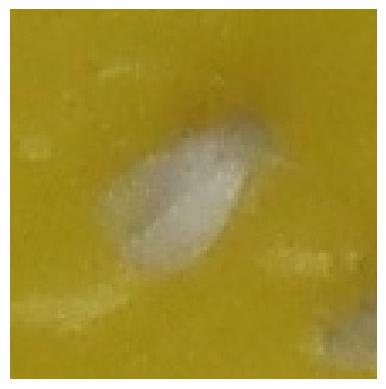

In [59]:
show(all_insects[3][80])

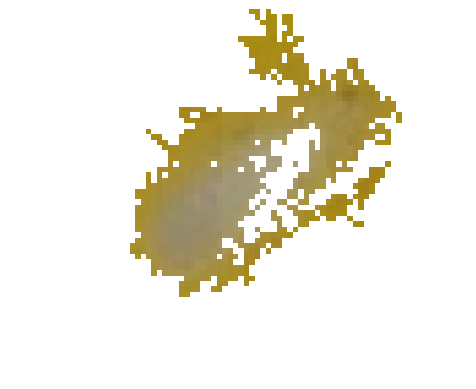

In [97]:
show(all_insects[3][1])

### Place the insects

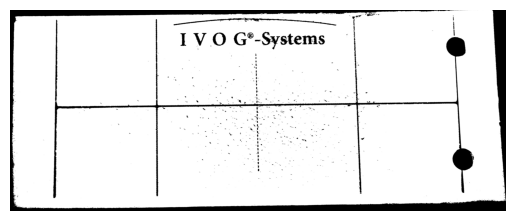

Placing insect index: 43
Placing insect index: 553
Placing insect index: 742
Placing insect index: 2329
Placing insect index: 463
Placing insect index: 1227
Placing insect index: 129
Placing insect index: 2223
Placing insect index: 554
Placing insect index: 2558
Placing insect index: 1364
Placing insect index: 1474
Placing insect index: 516
Placing insect index: 223
Placing insect index: 1905
Placing insect index: 1818
Placing insect index: 671
Placing insect index: 926
Placing insect index: 2036
Placing insect index: 1881
Placing insect index: 710
Placing insect index: 1546


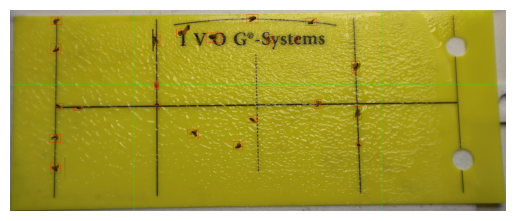

In [ ]:
empty_YST = sheared_YSTs[10].copy()
imageYST = find_contour(empty_YST)
x, y, w, h = cv2.boundingRect(imageYST)
empty_YST_cropped = empty_YST[y:y+h, x:x+w]
mask = create_binary_mask(empty_YST_cropped)

show(mask)
mask_binary = (mask < 128).astype(np.uint8)
mask_binary = remove_border_connected(mask_binary)
place_insects_by_region(empty_YST_cropped, mask_binary, all_insects[1],4)
show(empty_YST_cropped)


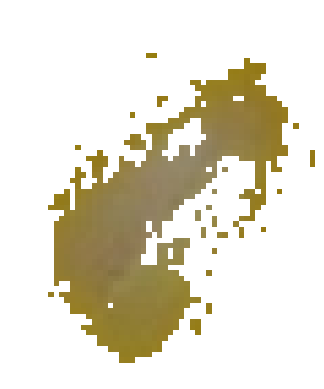

In [161]:
show(all_insects[3][0])

### The other idea: Place background behind existing tiles

In [117]:
def create_binary_mask_strong(image, binary_default=True):
    '''
    Binary masking with manual threshold (yellow)
    '''
    if binary_default:
        lower_yellow = np.array([20, 120, 120])
        upper_yellow = np.array([30, 255, 255])
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
        return mask
def crop(image):
    mask = create_binary_mask(image)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        cropped_image = image[y:y+h, x:x+w]
        return cropped_image, (x, y, w, h)
    else:
        return None, None
    
def show(img, title = None):
    '''
    plot an an cv2 image
    for use in notebooks
    '''
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    if title: plt.title(title) 
    plt.show()

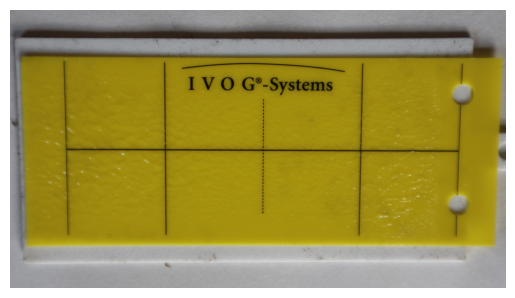

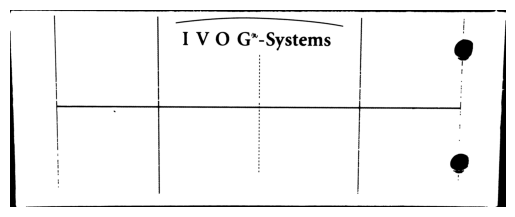

In [139]:
image_folder = "/user/christoph.wald/u15287/big-scratch/00_uncropped_dataset/emptyYST"
empty_YST = cv2.imread("/user/christoph.wald/u15287/big-scratch/00_uncropped_dataset/emptyYST/IMG_5885.JPG")
show(empty_YST)
empty_YST, _ = crop(empty_YST)
mask = create_binary_mask(empty_YST)
cleaned_mask = denoise_mask(mask)
show(cleaned_mask)

In [140]:
import cv2
import numpy as np

edges = cv2.Canny(mask, 50, 150)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=100, minLineLength=50, maxLineGap=10)


In [141]:
empty_YST.shape

(2318, 5835, 3)

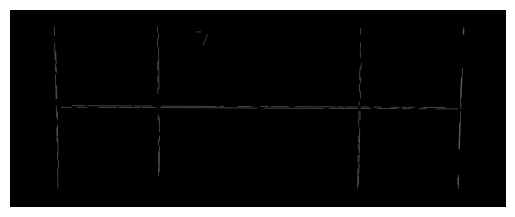

In [142]:
import cv2
import numpy as np

height, width, _ = empty_YST.shape
margin = 200  # pixels from the edge

filtered_lines = []

for line in lines:
    x1, y1, x2, y2 = line[0]  # HoughLinesP format
    
    # Keep only lines fully inside the image, ignoring a margin
    if (x1 >= margin and x1 <= width - margin and
        x2 >= margin and x2 <= width - margin and
        y1 >= margin and y1 <= height - margin and
        y2 >= margin and y2 <= height - margin):
        filtered_lines.append(line)

# Now draw only the filtered lines
blank_img = np.zeros((height, width), dtype=np.uint8)
for line in filtered_lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(blank_img, (x1, y1), (x2, y2), color=255, thickness=2)

    
show(blank_img)


In [143]:
lines = filtered_lines

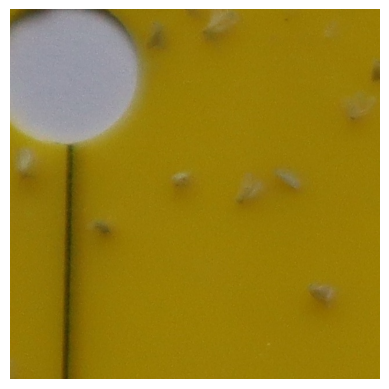

In [144]:
tile = cv2.imread("/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/tiles/images/val/TRIAVA_0362_tile_15.jpg")
#cv2.imwrite("tile.jpg", tile)
show(tile)


0 238 51 305


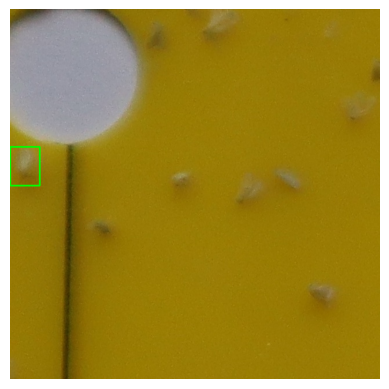

In [145]:
img_w, img_h = 640, 640
l = [3, 0.040320, 0.424834, 0.080640, 0.105195]

'''
3 0.040320 0.424834 0.080640 0.105195
3 0.246504 0.585994 0.084915 0.060536
3 0.474362 0.459874 0.105101 0.068942
3 0.649661 0.487620 0.110980 0.109303
3 0.846178 0.772449 0.100052 0.085759
3 0.756059 0.460669 0.089425 0.075670
3 0.943710 0.262200 0.108205 0.115609
3 0.577281 0.042468 0.116531 0.084936
3 0.398787 0.072447 0.079538 0.095259
'''

x_center = l[1] * img_w
y_center = l[2] * img_h
w = l[3] * img_w
h = l[4] * img_h

x1 = int(x_center - w/2)
y1 = int(y_center - h/2)
x2 = int(x_center + w/2)
y2 = int(y_center + h/2)

print(x1, y1, x2, y2)

tile_copy = tile.copy()
show(cv2.rectangle(tile_copy, (x1,y1), (x2,y2), color = (0,255,0), thickness=2))

In [146]:
# Assume we pick the first line for simplicity
line = lines[0][0]  # (x1, y1, x2, y2)

# Compute line center
line_center = ((line[0]+line[2])//2, (line[1]+line[3])//2)

# Compute box center
box_center = ((x1+x2)//2, (y1+y2)//2)

# Compute shift needed
shift_x = box_center[0] - line_center[0]
shift_y = box_center[1] - line_center[1]

# Shift large_img
M = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
shifted_large = cv2.warpAffine(empty_YST, M, (empty_YST.shape[1], empty_YST.shape[0]))
shifted_binary = cv2.warpAffine(cleaned_mask, M, (cleaned_mask.shape[1], cleaned_mask.shape[0]))


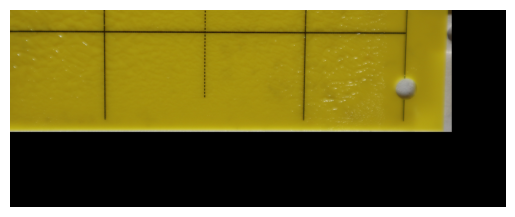

In [147]:
show(shifted_large)

In [148]:
h, w = tile.shape[:2]
start_x = max(0, box_center[0] - w//2)
start_y = max(0, box_center[1] - h//2)

patch_color = shifted_large[start_y:start_y+h, start_x:start_x+w]
patch_binary = shifted_binary[start_y:start_y+h, start_x:start_x+w]


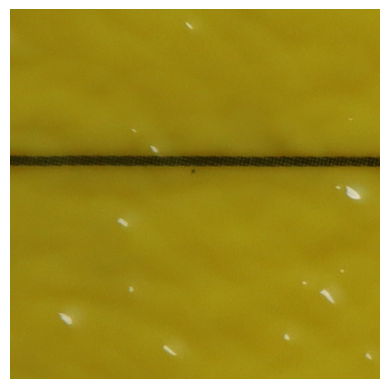

True

In [149]:
show(patch_color)
cv2.imwrite("background_tile.jpg", patch_color)

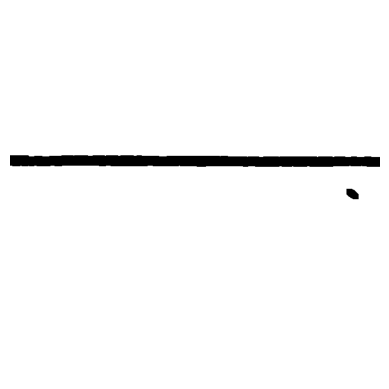

In [150]:
show(patch_binary)

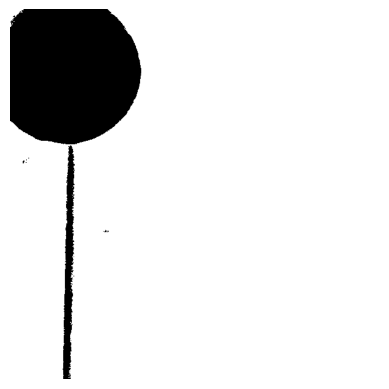

In [151]:
yellow_mask = create_binary_mask(tile)  # 255 = yellow background
yellow_mask_3c = cv2.merge([yellow_mask//255]*3)
show(yellow_mask)

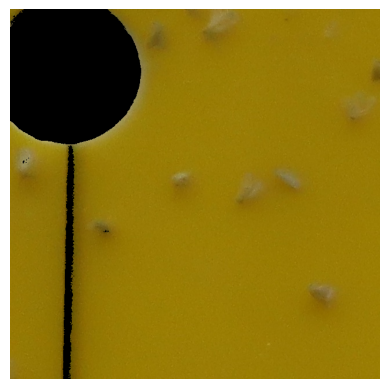

In [152]:
background_layer = tile.copy()
background_layer[yellow_mask_3c == 0] = 0  # keep only yellow background
show(background_layer)

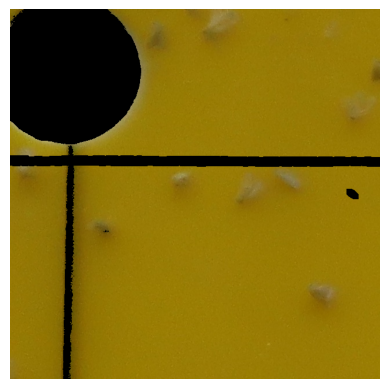

In [153]:
line_mask = (patch_binary == 255).astype(np.uint8)
line_mask_3c = cv2.merge([line_mask]*3)
merged = background_layer.copy()

# Overlay the black lines where line_mask_3c == 1
merged[line_mask_3c == 0] = 0
show(merged)

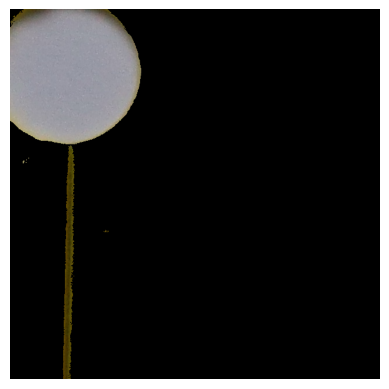

In [154]:
foreground_layer = np.zeros_like(tile)
foreground_layer[yellow_mask_3c == 0] = tile[yellow_mask_3c == 0]
show(foreground_layer)

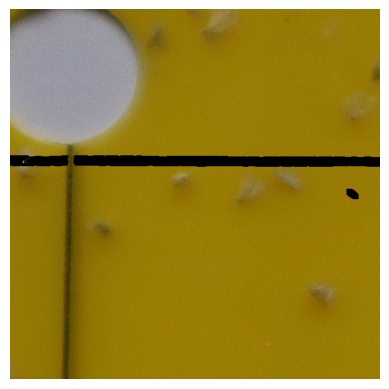

In [155]:
merged[yellow_mask_3c == 0] = tile[yellow_mask_3c == 0]
cv2.imwrite("new_tile.jpg", merged)
show(merged)

In [60]:

empty_image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/augmented_data/sheared_YSTs"
filenames = os.listdir(empty_image_folder)
sheared_YSTs = []
for filename in filenames:
    sheared_YSTs.append(cv2.imread(os.path.join(empty_image_folder, filename)))
print(f"Loaded {len(sheared_YSTs)} empty, augmented images.")

Loaded 18 empty, augmented images.


In [68]:
for YST in sheared_YSTs[1:2]:
    #show(YST)
    image = find_contour(YST)
    show(image)



error: OpenCV(4.11.0) /io/opencv/modules/imgproc/src/color.simd_helpers.hpp:92: error: (-15:Bad number of channels) in function 'cv::impl::{anonymous}::CvtHelper<VScn, VDcn, VDepth, sizePolicy>::CvtHelper(cv::InputArray, cv::OutputArray, int) [with VScn = cv::impl::{anonymous}::Set<3, 4>; VDcn = cv::impl::{anonymous}::Set<3, 4>; VDepth = cv::impl::{anonymous}::Set<0, 2, 5>; cv::impl::{anonymous}::SizePolicy sizePolicy = cv::impl::<unnamed>::NONE; cv::InputArray = const cv::_InputArray&; cv::OutputArray = const cv::_OutputArray&]'
> Invalid number of channels in input image:
>     'VScn::contains(scn)'
> where
>     'scn' is 2


In [64]:
find_contour(YST)

array([[[5712,  325]],

       [[5711,  326]],

       [[5703,  326]],

       ...,

       [[5721,  326]],

       [[5715,  326]],

       [[5714,  325]]], dtype=int32)

In [ ]:

    
    print(image is None)
    x,y,w,h = cv2.boundingRect(image)
    image = image[y:y+h, x:x+w]
 

    mask = create_binary_mask(image)
    mask_binary = (mask < 128).astype(np.uint8)
    mask_binary = remove_border_connected(mask_binary)

    idx_insects = counter % 3
    idx_augmentation = counter % 4

    print(idx_insects, idx_augmentation)